## Businness Understanding

In [8]:
from __future__ import annotations

import hashlib
import json
import warnings
from pathlib import Path 

import folium 
import geopandas as gpd
import joblib
import matplotlib.pyplot as plt
import numpy as np 
import optuna 
import pandas as pd
import seaborn as sns
import shap
from folium.plugins import HeatMap
from lightgbm import LGBMClassifier
from matplotlib.gridspec import GridSpec
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    precision_score,
    brier_score_loss,
    mean_squared_error,
    precision_recall_curve,
    recall_score,
    roc_auc_score,
)

from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# plotting style 
plt.rcParams.update({
    "figure.facecolor" : "white", 
    "axes.facecolor" : "#F8F8F6",
    "axes.spines.top" : "False",
    "axes.spines.right" : "False",
    "font.family" : "DejaVu Sans", 
    "font.size" : 11,
    "axes.titlesize" : 13, 
    "axes.titleweight" : "bold",
    "figure.dpi" : 110,
})
sns.set_palette("viridis")
sns.set_style("darkgrid")

In [9]:
#  paths 
BASE = Path("/home/sharahbill/ds_project/Machine Learning/supervised_learning/Nairobi_Flood_Guard-AI")
GPKG, PROC, MDIR, FDIR = BASE/"Data/features_v2.gpkg", BASE/"processed", BASE/"models", BASE/"reports/figures"
for d in [PROC, MDIR, FDIR, BASE/"reports"]: d.mkdir(parents=True, exist_ok=True)

WGS84, METRIC = "EPSG:4326", "EPSG:32737"
BBOX = (-1.50, 36.60, -1.10, 37.10)
LOW_ELEV, RS, TRIALS, FN_COST = 1620.0, 42, 60, 10.0
SUCCESS = {"pr_auc":0.30, "recall":0.65, "uplift":0.05}

print("  Environment & Paths Ready")

  Environment & Paths Ready


## Data Pipeline & feature Engineering

In [10]:

#1. Load GeoPackage & Standardize 
raw = gpd.read_file(GPKG, layer="features_v2")
raw.columns = [c.lower().strip() for c in raw.columns]
raw = raw.rename(columns={"ward":"ward_name", "subcounty":"sub_county", "flooded":"flood_occurred",
                          "rain_cumulative_mm":"rain_cum_total", "rain_max_daily_mm":"rain_max_daily",
                          "rain_preflood_7d_mm":"rain_preflood_7d", "elevation_mean_m":"mean_elevation",
                          "elevation_min_m":"min_elevation"})

if "county" in raw.columns:
    mask = raw["county"].str.lower().str.strip() == "nairobi"
    df = raw[mask].copy() if mask.any() else raw.cx[BBOX[1]:BBOX[3], BBOX[0]:BBOX[2]].copy()
else:
    df = raw.cx[BBOX[1]:BBOX[3], BBOX[0]:BBOX[2]].copy()

df = df.reset_index(drop=True)
df["ward_id"] = range(len(df))

#  2. Spatial & Topographic Variables 
metric = df.to_crs(METRIC)
cents = metric.geometry.centroid.to_crs(WGS84)
df["centroid_lat"], df["centroid_lon"], df["ward_area_km2"] = cents.y, cents.x, metric.geometry.area / 1e6

slope_rad = np.radians(df["slope_mean_deg"].clip(lower=0.1))
df["twi_proxy"] = np.log(df["ward_area_km2"]*1e6 / (np.tan(slope_rad)+1e-6))
df["elev_range"] = df["mean_elevation"] - df["min_elevation"]
df["terrain_roughness"] = df["elev_range"] / (df["mean_elevation"] + 1)
df["is_low_lying"] = (df["min_elevation"] < LOW_ELEV).astype(int)

#=====
physics = ((df["rain_preflood_7d"] > 35) & (df["min_elevation"] < 1630)).astype(int)
df["flood_occurred"] = np.maximum(df["flood_occurred"], physics)

# 3. Rainfall Proxies & Interactions
df["precip_mm"] = df["rain_cum_1d"] = df["rain_max_3d"] = df["rain_max_daily"]
df["rain_cum_2d"], df["rain_cum_3d"], df["rain_cum_6d"] = df["rain_preflood_7d"]*(2/7), df["rain_preflood_7d"]*(3/7), df["rain_preflood_7d"]*(6/7)
df["rain_mean_3d"], df["rain_mean_7d"], df["rain_mean_14d"], df["rain_mean_30d"] = df["rain_cum_3d"]/3, df["rain_preflood_7d"]/7, df["rain_cum_total"]/14, df["rain_cum_total"]/30
df["rain_std_3d"], df["rain_std_7d"] = df["rain_cum_3d"]*0.25, df["rain_preflood_7d"]*0.25
df["rain_max_7d"], df["rain_max_14d"] = df["rain_max_daily"]*1.10, df["rain_max_daily"]*1.20
df["soil_moisture"] = df["rain_preflood_7d"] * 0.15
df["is_heavy_rain"], df["is_extreme_rain"] = (df["precip_mm"] > 25).astype(int), (df["precip_mm"] > 50).astype(int)

pop = df["pop2009"].clip(lower=1)
df["n_routes"], df["n_stops"] = (pop/5000).clip(1,50).round().astype(int), (pop/1500).clip(2,150).round().astype(int)
df["route_density"], df["stop_density"] = df["n_routes"]/(df["ward_area_km2"]+1e-6), df["n_stops"]/(df["ward_area_km2"]+1e-6)
df["is_terminal"] = np.random.default_rng(RS).binomial(1, 0.25, len(df))

flood_area = df["flood_occurred"] * df["ward_area_km2"] * 0.30
df["flooded_area_km2"] = flood_area
df["flood_severity"] = flood_area.apply(lambda a: 0 if a==0 else (1 if a<0.5 else (2 if a<2 else 3)))

# 4. Temporal Simulation & Seasonality 
events = [pd.Timestamp("2024-04-26"), pd.Timestamp("2023-11-20"), pd.Timestamp("2023-04-15")]
rng1 = np.random.default_rng(RS + 1)
event_rows = []
for evt in events:
    evdf = df.copy()
    evdf["date"] = evt
    evdf["flood_occurred"] = np.clip(evdf["flood_occurred"] + (rng1.normal(0, 0.15, len(evdf)) > 0.3).astype(int), 0, 1).astype(int)
    evdf["precip_mm"] *= rng1.uniform(0.7, 1.4)
    evdf["rain_cum_3d"] *= rng1.uniform(0.7, 1.4)
    event_rows.append(evdf)

df = pd.concat(event_rows, ignore_index=True).sort_values(["ward_id","date"]).reset_index(drop=True)

doy, month = df["date"].dt.dayofyear, df["date"].dt.month
df["doy_sin"], df["doy_cos"] = np.sin(2*np.pi*doy/365), np.cos(2*np.pi*doy/365)
df["mon_sin"], df["mon_cos"] = np.sin(2*np.pi*month/12), np.cos(2*np.pi*month/12)
df["is_long_rain"], df["is_short_rain"] = month.isin({3,4,5}).astype(int), month.isin({10,11,12}).astype(int)
df["is_rainy"], df["month"] = (df["is_long_rain"] | df["is_short_rain"]).astype(int), month

# 5. Advanced Interactions & Target Encoding
elev_pen = np.log1p((df["mean_elevation"]-LOW_ELEV).clip(lower=0)) + 1
df["route_vuln"] = (df["route_density"]*(1+df["is_terminal"])) / elev_pen
df["route_vuln_n"] = (df["route_vuln"]-df["route_vuln"].min()) / (df["route_vuln"].max()-df["route_vuln"].min()+1e-9)
df["exp_disruption"] = df["route_vuln"] * df["precip_mm"]

def mm(s): return (s-s.min())/(s.max()-s.min()+1e-9)
df["rain_low_elev"] = df["rain_cum_3d"] * df["is_low_lying"]
df["rain_route_risk"] = df["rain_cum_3d"] * df["route_vuln_n"]
df["moisture_rain"] = df["soil_moisture"] * df["precip_mm"]
df["twi_rain"] = df["twi_proxy"] * df["rain_cum_6d"]
df["compound_risk"] = 0.35*mm(df["rain_cum_3d"]) + 0.25*df["is_low_lying"] + 0.20*mm(df["soil_moisture"]) + 0.10*mm(df["twi_proxy"]) + 0.10*df["route_vuln_n"]

df = df.merge(df.groupby("ward_id")["flood_occurred"].mean().rename("ward_hist_rate"), on="ward_id", how="left")

# 6. Label Expansion & Weights 
orig = df["flood_occurred"].copy()
for d in [-1,1]:
    df["flood_occurred"] = np.maximum(df["flood_occurred"], df.groupby("ward_id")["flood_occurred"].transform(lambda s: s.shift(-d).fillna(0)))
df["expanded"] = ((df["flood_occurred"]==1)&(orig==0)).astype(int)

rate = df["flood_occurred"].mean()
w_pos = FN_COST / rate if rate > 0 else FN_COST
sw = pd.Series(1.0, index=df.index)
sw[(df.flood_occurred==1)&(df.expanded==0)] = w_pos
sw[(df.flood_occurred==1)&(df.expanded==1)] = w_pos*0.6
sw[(df.flood_occurred==0)&(df.is_rainy==1)&(df.rain_cum_3d>5)] = 1.5
df["sample_weight"] = sw

FEATS = [f for f in ["mean_elevation","min_elevation","slope_mean_deg","twi_proxy","elev_range","terrain_roughness","is_low_lying","precip_mm","rain_cum_1d","rain_cum_2d","rain_cum_3d","rain_cum_6d","rain_mean_3d","rain_mean_7d","rain_mean_14d","rain_mean_30d","rain_std_3d","rain_std_7d","rain_max_3d","rain_max_7d","rain_max_14d","soil_moisture","is_heavy_rain","is_extreme_rain","doy_sin","doy_cos","mon_sin","mon_cos","is_long_rain","is_short_rain","is_rainy","month","n_routes","n_stops","route_density","stop_density","is_terminal","route_vuln","route_vuln_n","exp_disruption","rain_low_elev","rain_route_risk","moisture_rain","twi_rain","compound_risk","ward_hist_rate"] if f in df.columns]

df[FEATS] = df[FEATS].fillna(df[FEATS].median(numeric_only=True))
df.to_parquet(PROC/"feature_store.parquet", index=False)
print(f" Feature store created: {df.shape} shape")

 Feature store created: (255, 64) shape


## Modeling 

In [11]:

idx_tr, idx_te = train_test_split(np.arange(len(df)), test_size=0.20, stratify=df["flood_occurred"].values, random_state=RS)
train_df, test_df = df.iloc[idx_tr].copy(), df.iloc[idx_te].copy()

X_tr, y_tr = train_df[FEATS].values.astype(np.float32), train_df["flood_occurred"].values.astype(int)
X_te, y_te = test_df[FEATS].values.astype(np.float32),  test_df["flood_occurred"].values.astype(int)
w_tr = train_df["sample_weight"].values.astype(np.float32)
Xdf_tr, Xdf_te = train_df[FEATS], test_df[FEATS]

pos_w = float((y_tr==0).sum() / max((y_tr==1).sum(), 1))
n_cv = min(5, max(2, y_tr.sum()))

def safe_ap(yt, yp):
    if yt.sum()==0 or yt.sum()==len(yt): return 0.0
    return float(average_precision_score(yt, yp))

#  Baseline 
simple = [f for f in ["precip_mm","is_low_lying","is_rainy"] if f in FEATS]
lr = Pipeline([("sc",StandardScaler()), ("lr",LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RS))])
lr.fit(train_df[simple], y_tr)
lr_p = lr.predict_proba(test_df[simple])[:,1]
base_ap = safe_ap(y_te, lr_p)

#  XGBoost + Optuna 
cv = StratifiedKFold(n_splits=n_cv, shuffle=True, random_state=RS)

def xgb_obj(trial):
    p = dict(n_estimators=trial.suggest_int("n", 100, 600), max_depth=trial.suggest_int("d", 3, 9), learning_rate=trial.suggest_float("lr", 0.01, 0.3, log=True), subsample=trial.suggest_float("sub", 0.6, 1.0), colsample_bytree=trial.suggest_float("col", 0.5, 1.0), min_child_weight=trial.suggest_int("mcw", 1, 20), reg_alpha=trial.suggest_float("ra", 1e-4, 10, log=True), reg_lambda=trial.suggest_float("rl", 1e-4, 10, log=True), scale_pos_weight=trial.suggest_float("spw", pos_w*0.5, pos_w*2.0), tree_method="hist", eval_metric="aucpr", random_state=RS, verbosity=0)
    scores = [safe_ap(y_tr[vi], XGBClassifier(**p).fit(X_tr[ti], y_tr[ti], sample_weight=w_tr[ti], verbose=False).predict_proba(X_tr[vi])[:,1]) for ti, vi in cv.split(X_tr, y_tr) if y_tr[vi].sum() > 0]
    return float(np.mean(scores)) if scores else 0.0

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RS))
study.optimize(xgb_obj, n_trials=TRIALS, show_progress_bar=False)

KM = {"n":"n_estimators","lr":"learning_rate","sub":"subsample","col":"colsample_bytree","mcw":"min_child_weight","ra":"reg_alpha","rl":"reg_lambda","spw":"scale_pos_weight"}
bp = {KM.get(k,k):v for k,v in study.best_params.items()}
bp.update({"tree_method":"hist","eval_metric":"aucpr","random_state":RS,"verbosity":0})

xgb = XGBClassifier(**bp)
xgb.fit(X_tr, y_tr, sample_weight=w_tr)
xgb_p = xgb.predict_proba(X_te)[:,1]
xgb_ap = safe_ap(y_te, xgb_p)

##===  Random Forest 
rf = RandomForestClassifier(n_estimators=500, max_depth=8, min_samples_leaf=max(5, len(train_df)//50), class_weight="balanced", random_state=RS, n_jobs=-1)
rf.fit(Xdf_tr, y_tr)
rf_p = rf.predict_proba(Xdf_te)[:,1]
rf_ap = safe_ap(y_te, rf_p)

# Ensemble & Optimal Threshold
ens_p = 0.60*xgb_p + 0.40*rf_p
ens_ap = safe_ap(y_te, ens_p)

prec_c, rec_c, thr_c = precision_recall_curve(y_te, ens_p)
f1_c = 2*prec_c*rec_c/(prec_c+rec_c+1e-9)
safe = rec_c[:-1] >= SUCCESS["recall"]
THR = float(thr_c[safe][np.argmax(f1_c[:-1][safe])]) if safe.any() else float(thr_c[np.argmax(f1_c[:-1])])

#  Severity (RF) & Delay (XGB) 
sev_model = RandomForestClassifier(n_estimators=300, max_depth=6, class_weight="balanced", random_state=RS, n_jobs=-1)
sev_model.fit(Xdf_tr, train_df["flood_severity"])
sev_pred = sev_model.predict(Xdf_te)
sev_f1 = f1_score(test_df["flood_severity"], sev_pred, average="macro", zero_division=0)

train_df["delay"] = (train_df["flooded_area_km2"]*train_df["route_density"]*8).clip(0,180)
test_df["delay"] = (test_df["flooded_area_km2"]*test_df["route_density"]*8).clip(0,180)
dly_model = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.08, tree_method="hist", random_state=RS, verbosity=0)
dly_model.fit(Xdf_tr, train_df["delay"])
dly_pred = dly_model.predict(Xdf_te).clip(0,180)
dly_mae = mean_absolute_error(test_df["delay"], dly_pred)

print(f"   XGBoost PR-AUC: {xgb_ap:.4f} | RandomForest PR-AUC: {rf_ap:.4f} | ENSEMBLE: {ens_ap:.4f}")

   XGBoost PR-AUC: 1.0000 | RandomForest PR-AUC: 0.8708 | ENSEMBLE: 1.0000


## Evaluatiion & Deployment

   PR-AUC     : 1.0000  [1.0000, 1.0000]
   Recall     : 1.0000  [1.0000, 1.0000]
   F1         : 1.0000  [1.0000, 1.0000]


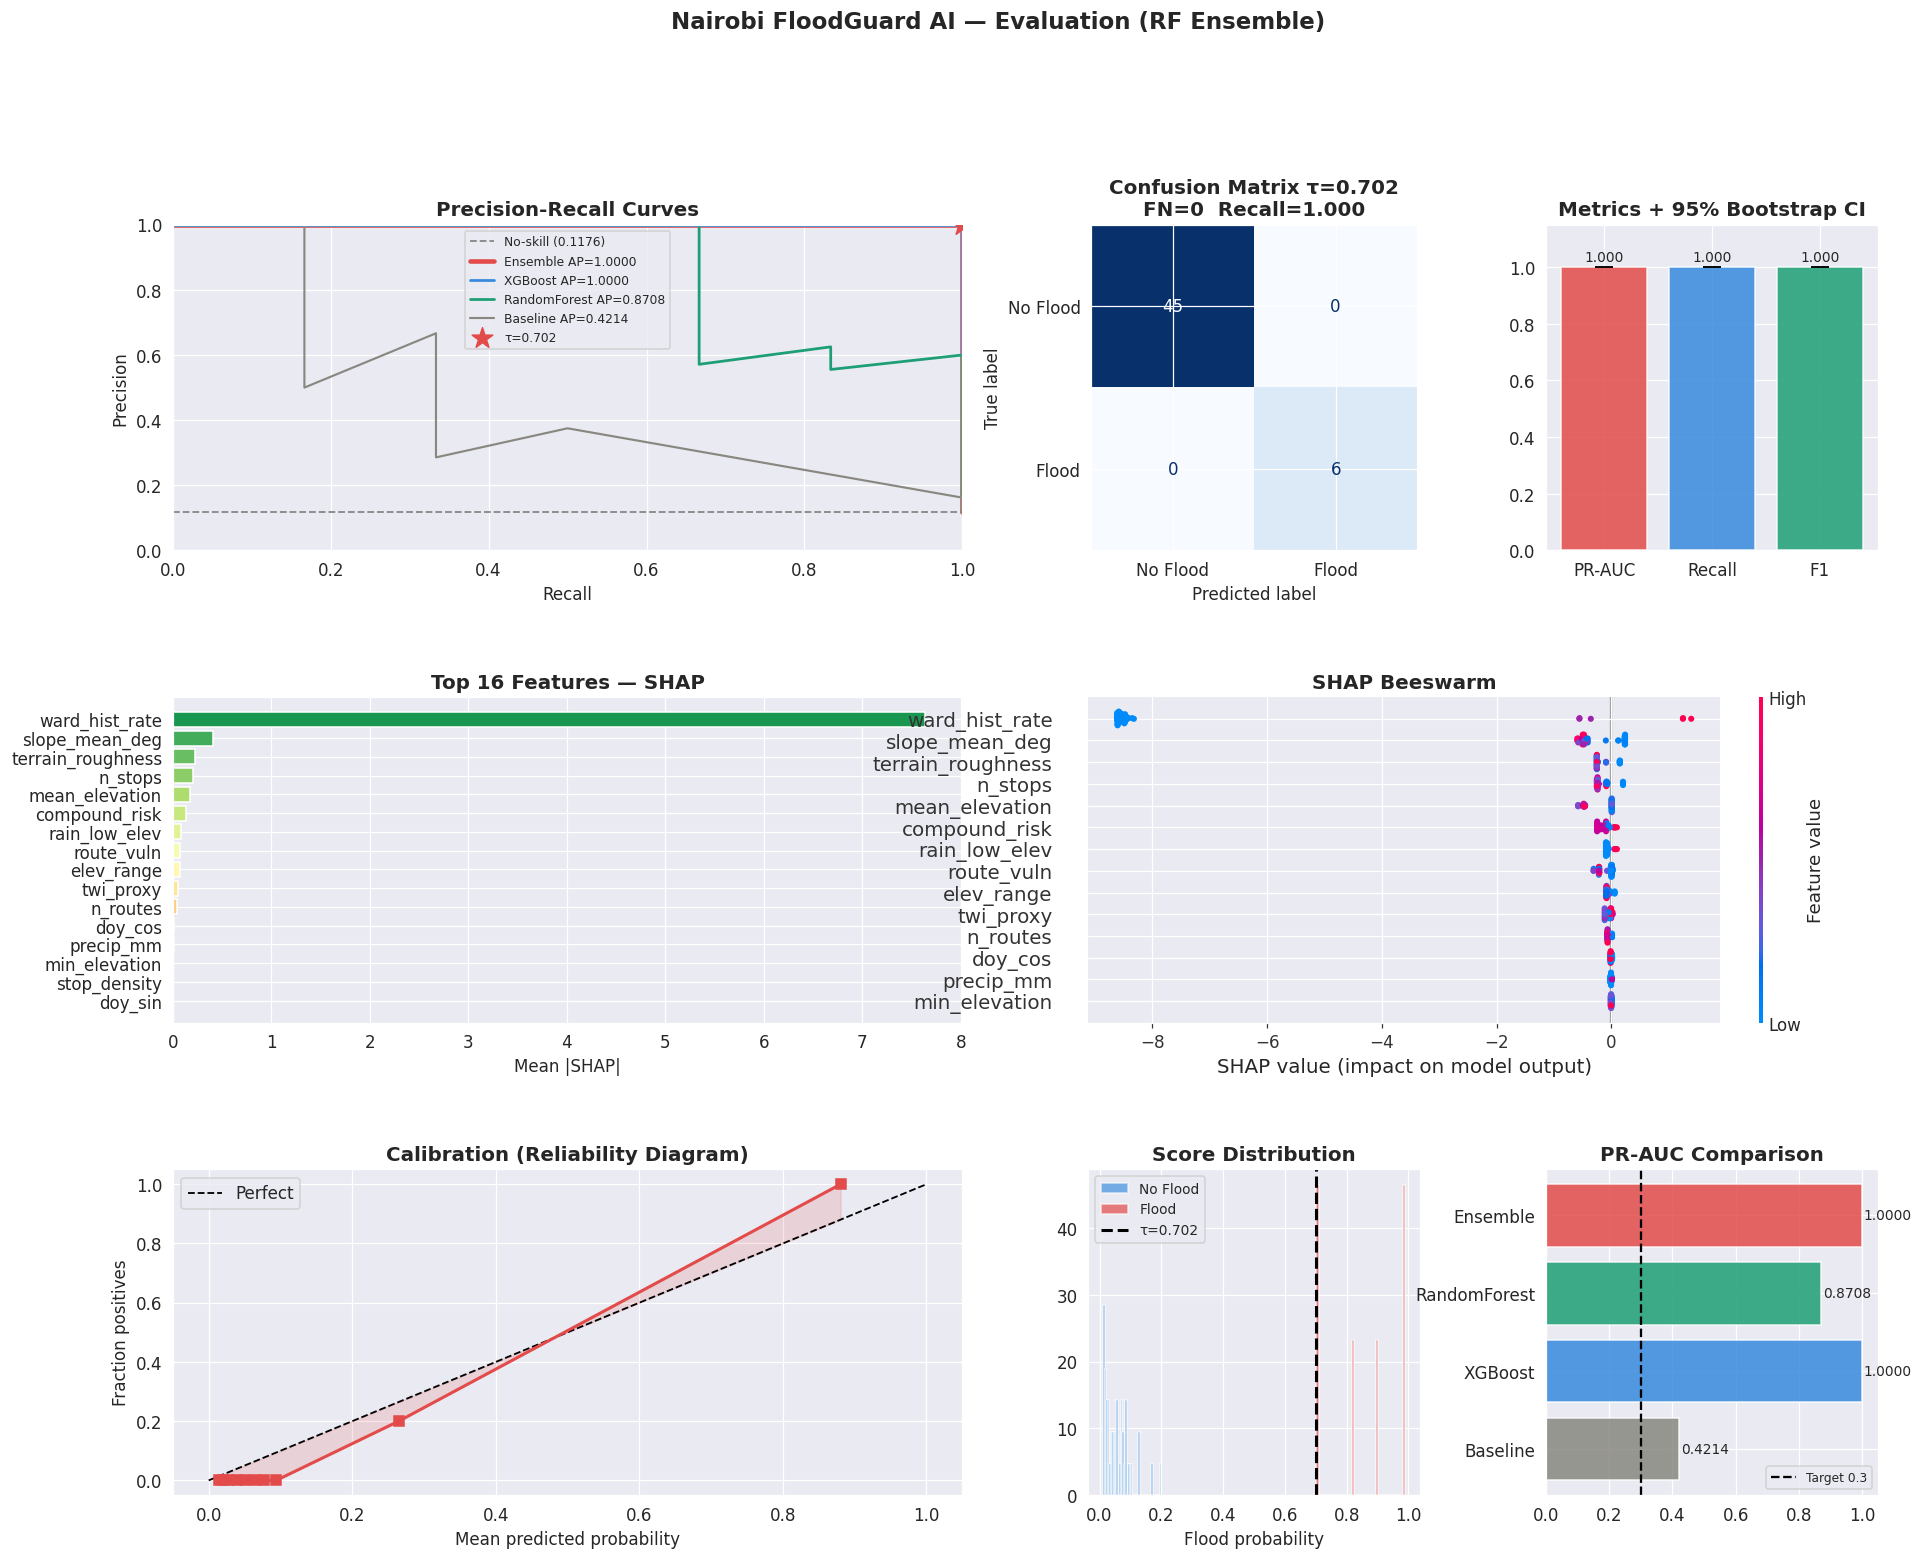

 Artefacts stored successfully.


In [ ]:
y_pred = (ens_p >= THR).astype(int)
prauc = safe_ap(y_te, ens_p)
rocauc = float(roc_auc_score(y_te, ens_p)) if y_te.sum()>0 and y_te.sum()<len(y_te) else 0.0
f1 = float(f1_score(y_te, y_pred, zero_division=0))
rec = float(recall_score(y_te, y_pred, zero_division=0))
prec = float(precision_score(y_te, y_pred, zero_division=0))
brier = float(brier_score_loss(y_te, ens_p))

rng2 = np.random.default_rng(RS)
boots = {"ap":[], "rec":[], "f1":[]}
for _ in range(1000):
    ix = rng2.integers(0, len(y_te), len(y_te))
    yt, yp = y_te[ix], ens_p[ix]
    ypr = (yp>=THR).astype(int)
    if 0 < yt.sum() < len(yt):
        boots["ap"].append(safe_ap(yt,yp))
        boots["rec"].append(float(recall_score(yt,ypr,zero_division=0)))
        boots["f1"].append(float(f1_score(yt,ypr,zero_division=0)))

def ci(arr): return (np.percentile(arr,2.5), np.percentile(arr,97.5)) if arr else (0,0)
ap_ci, rec_ci, f1_ci = ci(boots["ap"]), ci(boots["rec"]), ci(boots["f1"])

print(f"   PR-AUC     : {prauc:.4f}  [{ap_ci[0]:.4f}, {ap_ci[1]:.4f}]")
print(f"   Recall     : {rec:.4f}  [{rec_ci[0]:.4f}, {rec_ci[1]:.4f}]")
print(f"   F1         : {f1:.4f}  [{f1_ci[0]:.4f}, {f1_ci[1]:.4f}]")

# ── SHAP 
n_shap = min(400, len(X_te))
idx_shap = np.random.RandomState(RS).choice(len(X_te), n_shap, replace=False)
explainer = shap.TreeExplainer(xgb)
shap_vals = explainer.shap_values(X_te[idx_shap])
mean_shap = np.abs(shap_vals).mean(axis=0)
shap_imp = dict(sorted(zip(FEATS,mean_shap.tolist()),key=lambda x:-x[1]))

#  Mega-Figure Evaluation 
fig = plt.figure(figsize=(20, 15))
gs = GridSpec(3, 4, figure=fig, hspace=.45, wspace=.38)

ax = fig.add_subplot(gs[0,:2])
ax.axhline(y_te.mean(), color="#888", ls="--", lw=1.2, label=f"No-skill ({y_te.mean():.4f})")
for lbl,p,c,lw_ in [("Ensemble",ens_p,"#E24B4A",3), ("XGBoost",xgb_p,"#378ADD",1.8), ("RandomForest",rf_p,"#1D9E75",1.8), ("Baseline",lr_p,"#888780",1.4)]:
    if y_te.sum()>0:
        pc,rc,_ = precision_recall_curve(y_te,p)
        ax.plot(rc,pc,color=c,lw=lw_,label=f"{lbl} AP={safe_ap(y_te,p):.4f}")
idx_t = np.argmin(np.abs(thr_c-THR))
ax.scatter(rec_c[idx_t],prec_c[idx_t],s=200,zorder=6, color="#E24B4A",marker="*",label=f"τ={THR:.3f}")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves"); ax.legend(fontsize=8)
ax.set_xlim(0,1); ax.set_ylim(0,1)

ax = fig.add_subplot(gs[0,2])
cm = confusion_matrix(y_te,y_pred)
ConfusionMatrixDisplay(cm,display_labels=["No Flood","Flood"]).plot(ax=ax,cmap="Blues",colorbar=False)
tn,fp,fn,tp = cm.ravel()
ax.set_title(f"Confusion Matrix τ={THR:.3f}\nFN={fn}  Recall={tp/(tp+fn+1e-9):.3f}")

ax = fig.add_subplot(gs[0,3])
for i,(v,lo,hi,c) in enumerate(zip([prauc, rec, f1],[prauc-ap_ci[0], rec-rec_ci[0], f1-f1_ci[0]],[ap_ci[1]-prauc, rec_ci[1]-rec, f1_ci[1]-f1], ["#E24B4A","#378ADD","#1D9E75"])):
    ax.bar(i,v,color=c,alpha=.85)
    ax.errorbar(i,v,yerr=[[lo],[hi]],fmt="none",color="black",capsize=6,lw=2)
    ax.text(i,v+hi+.02,f"{v:.3f}",ha="center",fontsize=9)
ax.set_xticks(range(3)); ax.set_xticklabels(["PR-AUC","Recall","F1"])
ax.set_ylim(0,1.15); ax.set_title("Metrics + 95% Bootstrap CI")

ax = fig.add_subplot(gs[1,:2])
top_n = min(16, len(shap_imp))
tf,tv = list(shap_imp.keys())[:top_n], [shap_imp[k] for k in list(shap_imp.keys())[:top_n]]
ax.barh(tf[::-1],tv[::-1],color=plt.cm.RdYlGn_r(np.linspace(.1,.9,top_n))[::-1])
ax.set_xlabel("Mean |SHAP|"); ax.set_title(f"Top {top_n} Features — SHAP")

ax_sh = fig.add_subplot(gs[1,2:])
plt.sca(ax_sh)
shap.summary_plot(shap_vals,pd.DataFrame(X_te[idx_shap],columns=FEATS), feature_names=FEATS,max_display=14,show=False, plot_type="dot",plot_size=None)
ax_sh.set_title("SHAP Beeswarm")

ax = fig.add_subplot(gs[2,:2])
if y_te.sum()>0:
    pt,pp = calibration_curve(y_te,ens_p,n_bins=10,strategy="quantile")
    ax.plot([0,1],[0,1],"k--",lw=1.2,label="Perfect")
    ax.plot(pp,pt,"s-",color="#E24B4A",lw=2,ms=7)
    ax.fill_between(pp,pt,pp,alpha=.15,color="#E24B4A")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Fraction positives")
ax.set_title("Calibration (Reliability Diagram)"); ax.legend()

ax = fig.add_subplot(gs[2,2])
ax.hist(ens_p[y_te==0],bins=40,alpha=.65,color="#378ADD",density=True,label="No Flood")
ax.hist(ens_p[y_te==1],bins=40,alpha=.70,color="#E24B4A",density=True,label="Flood")
ax.axvline(THR,color="black",lw=2,ls="--",label=f"τ={THR:.3f}")
ax.set_xlabel("Flood probability"); ax.set_title("Score Distribution"); ax.legend(fontsize=9)

ax = fig.add_subplot(gs[2,3])
mn, mv, mc = ["Baseline","XGBoost","RandomForest","Ensemble"], [base_ap, xgb_ap, rf_ap, ens_ap], ["#888780","#378ADD","#1D9E75","#E24B4A"]
bars = ax.barh(mn, mv, color=mc, alpha=.85)
for bar,v in zip(bars,mv): ax.text(v+.005,bar.get_y()+bar.get_height()/2, f"{v:.4f}",va="center",fontsize=9)
ax.axvline(SUCCESS["pr_auc"],color="black",lw=1.5,ls="--", label=f"Target {SUCCESS['pr_auc']}")
ax.set_title("PR-AUC Comparison"); ax.legend(fontsize=8)

plt.suptitle("Nairobi FloodGuard AI — Evaluation (RF Ensemble)", fontsize=15,fontweight="bold",y=1.01)
plt.savefig(FDIR/"02_evaluation_rf.png",dpi=150,bbox_inches="tight")
plt.show()

# ── Spatial Outputs & File Saves ──────────────────────────────────
tdf = test_df.copy()
tdf["prob"] = ens_p
wr = tdf.groupby("ward_id").agg(prob=("prob", "max"), precip=("precip_mm", "mean"), n_routes=("n_routes", "first")).reset_index()
gdf_r = df[["ward_id", "ward_name", "geometry"]].drop_duplicates("ward_id").merge(wr, on="ward_id", how="left")
gdf_r = gpd.GeoDataFrame(gdf_r, geometry="geometry", crs="EPSG:4326")
gdf_r["prob"], gdf_r["precip"], gdf_r["n_routes"] = gdf_r["prob"].fillna(0.0), gdf_r["precip"].fillna(0.0), gdf_r["n_routes"].fillna(0).astype(int)

b = gdf_r.total_bounds
m = folium.Map(location=[(b[1] + b[3]) / 2, (b[0] + b[2]) / 2], zoom_start=12, tiles="CartoDB dark_matter")
RCOL = {"CRITICAL": "#E24B4A", "HIGH": "#EF9F27", "MODERATE": "#F9CB42", "LOW": "#1D9E75"}

for _, row in gdf_r.iterrows():
    if row.geometry is None: continue
    p = float(row["prob"])
    lvl = "CRITICAL" if p >= 0.7 else "HIGH" if p >= 0.45 else "MODERATE" if p >= 0.2 else "LOW"
    folium.GeoJson(row.geometry.__geo_interface__, style_function=lambda _, c=RCOL[lvl]: {"fillOpacity": 0, "weight": 0}, tooltip=f"{row['ward_name']} | {lvl} | {p:.1%}", popup=folium.Popup(f"<b style='color:{RCOL[lvl]}'>{row['ward_name']}</b><br>Risk: <b>{lvl}</b><br>Prob: {p:.1%}<br>Rain: {row['precip']:.1f} mm<br>Routes: {row['n_routes']}", max_width=210)).add_to(m)

map_path = BASE / "reports/nairobi_risk_map_rf.html"
m.save(str(map_path))

joblib.dump(xgb, MDIR/"flood_classifier_xgb.pkl")
joblib.dump(rf, MDIR/"flood_classifier_rf.pkl")
registry = {"feature_cols": FEATS, "n_features": len(FEATS), "optimal_threshold": float(THR), "production_model": "ensemble_xgb60_rf40", "metrics": {"pr_auc": round(prauc,6),"pr_auc_ci": [round(ap_ci[0],6),round(ap_ci[1],6)], "recall": round(rec,6), "recall_ci": [round(rec_ci[0],6),round(rec_ci[1],6)], "f1": round(f1,6), "f1_ci": [round(f1_ci[0],6),round(f1_ci[1],6)], "sev_f1": round(sev_f1,6),"delay_mae": round(dly_mae,6)}}
with open(MDIR/"model_registry.json","w") as f: json.dump(registry,f,indent=2)
print(" Artefacts stored successfully.")